C:\Users\User\AppData\Local\Temp\ipykernel_18168\3957963170.py:13: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('total.csv')


Original Class Distribution:
 Label
0    2273097
1     557647
Name: count, dtype: int64

Class Distribution After SMOTE:
0    2273097
1    1115294
Name: count, dtype: int64

Evaluating with 1% of attack samples

Class Distribution:
0    2273097
1      11152
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9076
Recall: 0.9577
F1-Score: 0.9320
MCC: 0.9320
Balanced Accuracy: 0.9786

🔹 **Confusion Matrix:**
[[454283    228]
 [    99   2240]]

Evaluating with 5% of attack samples

Class Distribution:
0    2273097
1      55764
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9679
Recall: 0.9895
F1-Score: 0.9786
MCC: 0.9781
Balanced Accuracy: 0.9943

🔹 **Confusion Matrix:**
[[454265    366]
 [   117  11025]]

Evaluating with 10% of attack samples

Class Distribution:
0    2273097
1     111529
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Precision: 0.9822
Recall: 0.9964
F1-Score: 0.9892
MCC: 0.9887
Balanced Accuracy: 0.9977

🔹 **Co

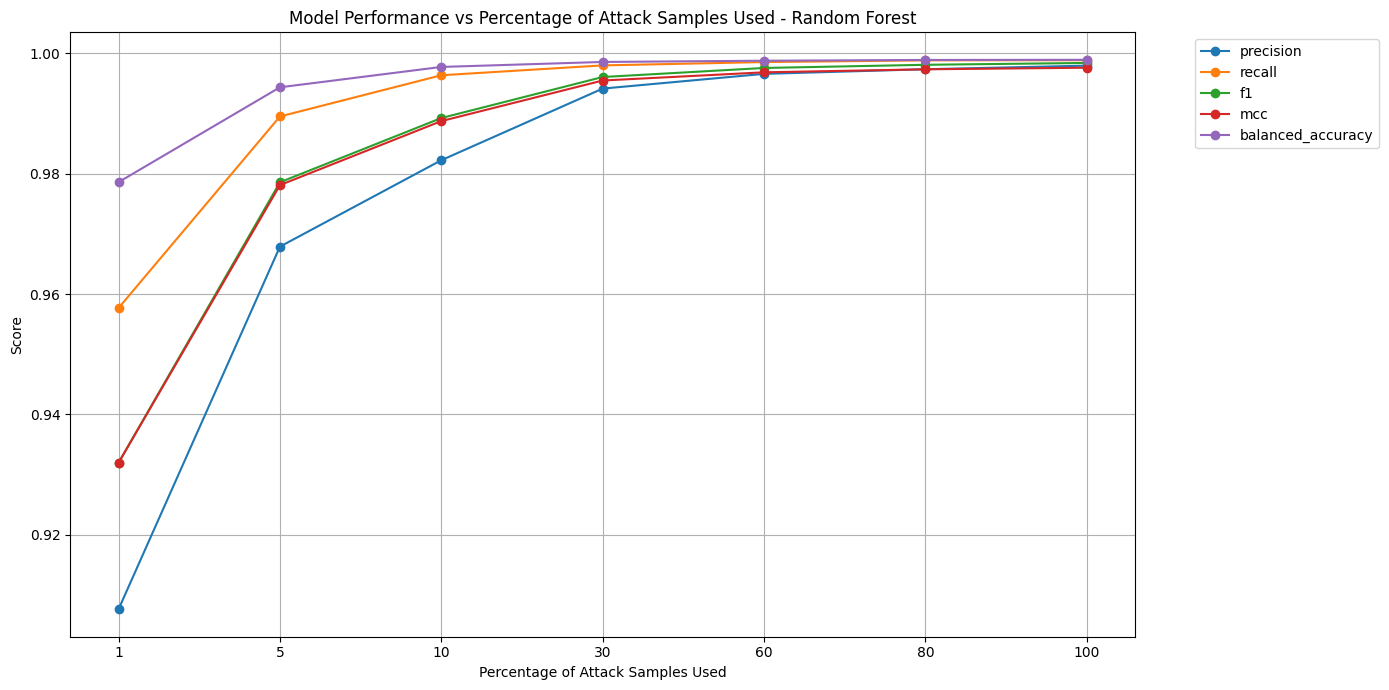

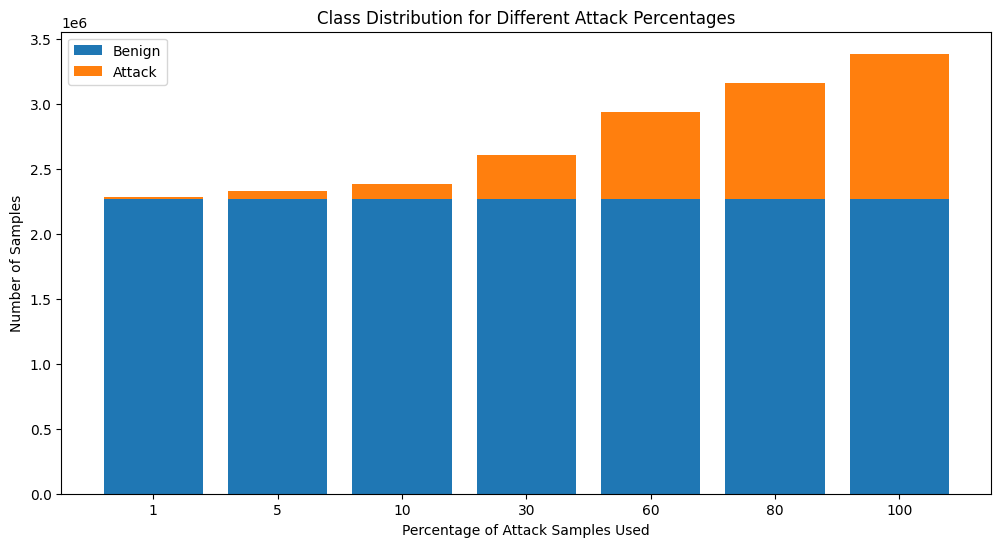

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                           confusion_matrix, matthews_corrcoef, 
                           balanced_accuracy_score)
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('total.csv')

# Define selected features
selected_columns = [
    ' Avg Fwd Segment Size', ' Fwd Packet Length Mean', ' Fwd Packet Length Max', 
    ' Subflow Fwd Bytes', ' Average Packet Size', 'Total Length of Fwd Packets', 
    ' Packet Length Std', ' Packet Length Variance', ' Bwd Packet Length Mean', 
    ' PSH Flag Count', 'Init_Win_bytes_forward', ' Bwd Packet Length Std', 
    'Bwd Packet Length Max', ' Max Packet Length', ' Fwd Header Length', 
    ' Packet Length Mean', ' Total Length of Bwd Packets', ' Bwd Packets/s', 
    ' act_data_pkt_fwd', ' Init_Win_bytes_backward', 'Flow Bytes/s', 
    ' Subflow Bwd Bytes', ' Bwd Header Length', ' ACK Flag Count', ' Fwd IAT Std',' Label'
]

target_column = ' Label'  

# Ensure all selected columns exist
missing_columns = [col for col in selected_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# Keep only selected features and target variable
df = df[selected_columns]

# Convert target labels
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Print class distribution
print("Original Class Distribution:")
print(df[' Label'].value_counts())

# Separate features and target
X = df.drop(columns=[' Label'])
y = df[' Label'].values

# Handle missing & infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Apply imputation
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# --- Manual SMOTE Implementation ---
def smote(X, y, k=5, oversampling_ratio=1.0):
    # Identify the minority class
    unique, counts = np.unique(y, return_counts=True)
    minority_class = unique[np.argmin(counts)]  # Find minority class
    X_minority = X[y == minority_class]
    n_minority = X_minority.shape[0]

    # Compute the number of synthetic samples needed
    n_synthetic = int(n_minority * oversampling_ratio)

    # Initialize an array to store synthetic samples
    synthetic_samples = np.zeros((n_synthetic, X.shape[1]))

    # Use KNN to find neighbors
    knn = NearestNeighbors(n_neighbors=min(k, n_minority))  # Avoid errors if samples are too few
    knn.fit(X_minority)

    # Generate synthetic samples
    for i in range(n_synthetic):
        # Randomly select a minority sample
        idx = np.random.randint(0, n_minority)
        sample = X_minority[idx]

        # Find k-nearest neighbors
        _, neighbors = knn.kneighbors(sample.reshape(1, -1))

        # Select one of the neighbors randomly
        neighbor_idx = np.random.choice(neighbors[0])
        neighbor = X_minority[neighbor_idx]

        # Create synthetic sample
        diff = neighbor - sample
        synthetic_sample = sample + np.random.rand() * diff
        synthetic_samples[i] = synthetic_sample

    # Combine original and synthetic samples
    X_resampled = np.vstack((X, synthetic_samples))
    y_resampled = np.hstack((y, np.full(n_synthetic, minority_class)))

    return X_resampled, y_resampled

# Apply SMOTE to create balanced dataset
X_resampled, y_resampled = smote(X, y, oversampling_ratio=1.0)

# Check the class distribution after SMOTE
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_resampled).value_counts())

# Function to create datasets with different percentages of attack samples
def create_dataset_with_attack_percentage(X_full, y_full, percentage):
    # Split into benign and attack
    X_benign = X_full[y_full == 0]
    y_benign = y_full[y_full == 0]
    X_attack = X_full[y_full == 1]
    y_attack = y_full[y_full == 1]
    
    # Calculate number of attack samples to use
    n_attack_total = len(X_attack)
    n_attack_use = int(n_attack_total * percentage / 100)
    
    # Randomly select attack samples
    attack_indices = np.random.choice(n_attack_total, n_attack_use, replace=False)
    X_attack_sampled = X_attack[attack_indices]
    y_attack_sampled = y_attack[attack_indices]
    
    # Combine with all benign samples
    X_balanced = np.vstack((X_benign, X_attack_sampled))
    y_balanced = np.hstack((y_benign, y_attack_sampled))
    
    return X_balanced, y_balanced

# Define attack percentages to test
attack_percentages = [1, 5, 10, 30, 60, 80, 100]

# Dictionary to store results
results = {}

for percentage in attack_percentages:
    print(f"\n{'='*50}")
    print(f"Evaluating with {percentage}% of attack samples")
    print(f"{'='*50}")
    
    # Create dataset with specific percentage of attack samples
    X_percentage, y_percentage = create_dataset_with_attack_percentage(X_resampled, y_resampled, percentage)
    
    # Check the class distribution
    class_distribution = pd.Series(y_percentage).value_counts()
    print("\nClass Distribution:")
    print(class_distribution)
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_percentage, y_percentage, test_size=0.2, random_state=42)
    
    # Initialize the Random Forest classifier
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
    
    # Train the model
    rf_classifier.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = rf_classifier.predict(X_test)
    
    # Compute Performance Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    # Store results
    results[percentage] = {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mcc': mcc,
        'balanced_accuracy': balanced_acc,
        'class_distribution': class_distribution.to_dict()
    }
    
    # Print Performance Metrics
    print("\n🔹 **Model Performance Metrics:**")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    
    # Print Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("\n🔹 **Confusion Matrix:**")
    print(conf_matrix)

# Compare results
print("\n\n🔹🔹🔹 **Final Comparison of All Approaches** 🔹🔹🔹")
print("{:<10} {:<12} {:<12} {:<12} {:<12} {:<12}".format(
    "Attack%", "Precision", "Recall", "F1", "MCC", "Balanced Acc"))
for percentage, metrics in results.items():
    print("{:<10} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f} {:<12.4f}".format(
        str(percentage),
        metrics['precision'],
        metrics['recall'],
        metrics['f1'],
        metrics['mcc'],
        metrics['balanced_accuracy']))

# Plot comparison
metrics_to_plot = ['precision', 'recall', 'f1', 'mcc', 'balanced_accuracy']
x_labels = [str(p) for p in attack_percentages]

plt.figure(figsize=(14, 7))
for metric in metrics_to_plot:
    values = [results[p][metric] for p in attack_percentages]
    plt.plot(x_labels, values, marker='o', label=metric)

plt.title('Model Performance vs Percentage of Attack Samples Used - Random Forest')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot class distribution for each percentage
plt.figure(figsize=(12, 6))
attack_counts = []
benign_counts = []

for percentage in attack_percentages:
    dist = results[percentage]['class_distribution']
    benign_counts.append(dist[0])
    attack_counts.append(dist[1])

plt.bar([str(p) for p in attack_percentages], benign_counts, label='Benign')
plt.bar([str(p) for p in attack_percentages], attack_counts, bottom=benign_counts, label='Attack')
plt.title('Class Distribution for Different Attack Percentages')
plt.xlabel('Percentage of Attack Samples Used')
plt.ylabel('Number of Samples')
plt.legend()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9112\1692827492.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('total.csv')


Class Distribution:
 Label
0    2273097
1     557647
Name: count, dtype: int64

🔹 **Model Performance Metrics:**
Accuracy: 0.9988
Precision: 0.9955
Recall: 0.9985
F1-Score: 0.9970
AUC-ROC: 0.9987

🔹 **Confusion Matrix:**
[[454014    506]
 [   170 111459]]


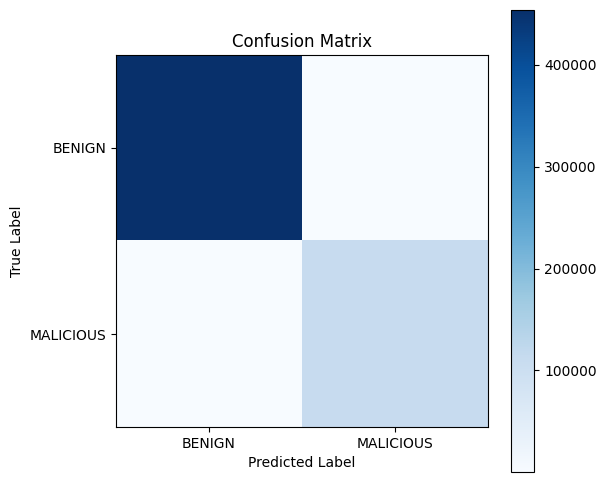

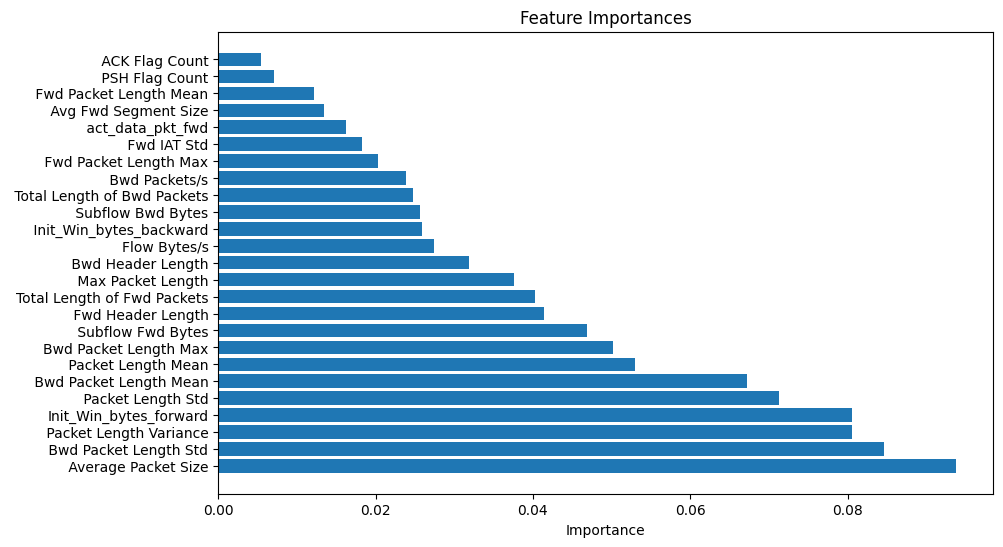

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('total.csv')

# Define selected features
selected_columns = [
    ' Avg Fwd Segment Size', ' Fwd Packet Length Mean', ' Fwd Packet Length Max', 
    ' Subflow Fwd Bytes', ' Average Packet Size', 'Total Length of Fwd Packets', 
    ' Packet Length Std', ' Packet Length Variance', ' Bwd Packet Length Mean', 
    ' PSH Flag Count', 'Init_Win_bytes_forward', ' Bwd Packet Length Std', 
    'Bwd Packet Length Max', ' Max Packet Length', ' Fwd Header Length', 
    ' Packet Length Mean', ' Total Length of Bwd Packets', ' Bwd Packets/s', 
    ' act_data_pkt_fwd', ' Init_Win_bytes_backward', 'Flow Bytes/s', 
    ' Subflow Bwd Bytes', ' Bwd Header Length', ' ACK Flag Count', ' Fwd IAT Std',' Label'
]

target_column = ' Label'  

# Ensure all selected columns exist
missing_columns = [col for col in selected_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

# Keep only selected features and target variable
df = df[selected_columns]

# Convert target labels
df[' Label'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Print class distribution
print("Class Distribution:")
print(df[' Label'].value_counts())

# Separate features and target
X = df.drop(columns=[' Label'])
y = df[' Label'].values

# Handle missing & infinite values
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Apply imputation
#imputer = SimpleImputer(strategy='mean')
#X = imputer.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Compute Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)

# Print Performance Metrics
print("\n🔹 **Model Performance Metrics:**")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

# Print Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\n🔹 **Confusion Matrix:**")
print(conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['BENIGN', 'MALICIOUS'])
plt.yticks(tick_marks, ['BENIGN', 'MALICIOUS'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Feature Importance (Optional)
importances = rf_classifier.feature_importances_
feature_importances = pd.DataFrame({'Feature': selected_columns[:-1], 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()